In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

## Config

한 프롬프트에 대해 **20개의 seed**로 이미지를 생성하고 **하나의 grid 이미지**로 합쳐 저장.

In [ ]:
import gc
import re
import math
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusion3Pipeline

DEVICE         = "cuda"
MODEL_ID       = "stabilityai/stable-diffusion-3-medium-diffusers"
NUM_STEPS      = 28
GUIDANCE_SCALE = 7.0

PROMPT = "the Colosseum Rome Italy carry-all pouch" # a car shaped like a violin made of clouds
SEEDS  = list(range(20))   # 0..19

# grid layout (rows x cols). 20 seeds → 4 x 5
N_COLS = 5
N_ROWS = math.ceil(len(SEEDS) / N_COLS)

PROMPT_SLUG = re.sub(r"[^a-zA-Z0-9]+", "_", PROMPT).strip("_").lower()
OUTPUT_DIR  = Path("./output/multi_seed") / PROMPT_SLUG
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"prompt : {PROMPT!r}")
print(f"seeds  : {SEEDS}")
print(f"grid   : {N_ROWS} x {N_COLS}")
print(f"out    : {OUTPUT_DIR}")

/home/haeun/miniconda3/envs/C3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


prompt : 'The Colosseum Rome Italy Carry-all Pouch'
seeds  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
grid   : 4 x 5
out    : output/multi_seed/the_colosseum_rome_italy_carry_all_pouch


## Load Pipeline

In [3]:
pipe = StableDiffusion3Pipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
).to(DEVICE)
pipe.set_progress_bar_config(disable=True)

Loading pipeline components...: 100%|██████████| 9/9 [00:02<00:00,  4.30it/s]


## Generate

In [4]:
def generate(prompt, seed):
    generator = torch.Generator(device=pipe.device).manual_seed(seed)
    image = pipe(
        prompt,
        num_inference_steps=NUM_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        generator=generator,
    ).images[0]
    torch.cuda.empty_cache(); gc.collect()
    return image

images = {}
for i, seed in enumerate(SEEDS):
    print(f"[{i+1:>2}/{len(SEEDS)}] seed={seed}")
    images[seed] = generate(PROMPT, seed)

[ 1/20] seed=0
[ 2/20] seed=1
[ 3/20] seed=2
[ 4/20] seed=3
[ 5/20] seed=4
[ 6/20] seed=5
[ 7/20] seed=6
[ 8/20] seed=7
[ 9/20] seed=8
[10/20] seed=9
[11/20] seed=10
[12/20] seed=11
[13/20] seed=12
[14/20] seed=13
[15/20] seed=14
[16/20] seed=15
[17/20] seed=16
[18/20] seed=17
[19/20] seed=18
[20/20] seed=19


## Plot grid & save

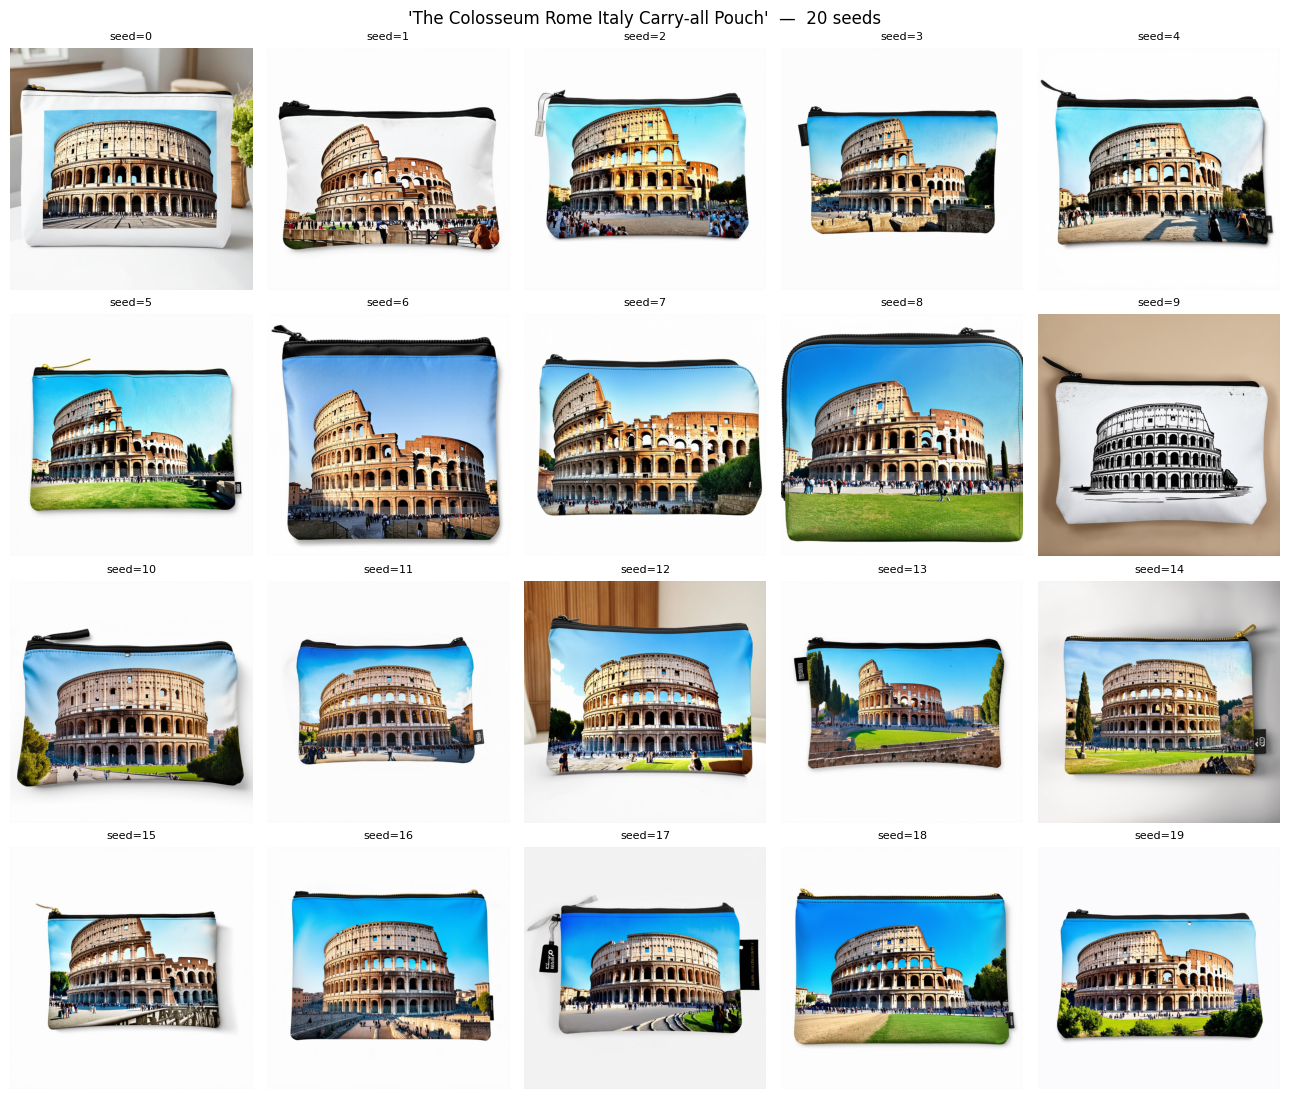

saved -> output/multi_seed/the_colosseum_rome_italy_carry_all_pouch/grid_seeds0-19.png


In [5]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 2.6, N_ROWS * 2.8), squeeze=False)

for idx, seed in enumerate(SEEDS):
    r, c = divmod(idx, N_COLS)
    ax = axes[r][c]
    ax.imshow(images[seed])
    ax.set_title(f"seed={seed}", fontsize=8)
    ax.axis("off")

# leftover cells
for idx in range(len(SEEDS), N_ROWS * N_COLS):
    r, c = divmod(idx, N_COLS)
    axes[r][c].axis("off")

fig.suptitle(f"{PROMPT!r}  —  {len(SEEDS)} seeds", fontsize=12)
plt.tight_layout()
out = OUTPUT_DIR / f"grid_seeds{SEEDS[0]}-{SEEDS[-1]}.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.show()
print(f"saved -> {out}")